In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_columns')
#pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

# EDA

In [8]:
df_treino = pd.read_csv('train.csv')
#df_treino = df_treino.drop(['Id'],axis=1)
#df_treino
df_treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
pd.set_option('display.max_rows', None)
df_treino.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [13]:
#df_treino.select_dtypes(['int64','float64']).drop(['Id'],axis=1).corr()
df_treino_numericas = df_treino.select_dtypes(['int64','float64'])
#df_treino_numericas

Podemos ver que em vários casos, há uma alta correlação, o que torna trabalhoso e demorado tratar os dados para usar uma regressão linear multivalorada. 

Poderíamos inclusive fazer algum agrupamento entre os grandes grupos de variáveis. Por exemplo: há 2 variáveis categóricas que descrevem Roof; há 9 variáveis ( entre numéricas e categóricas) que descrevem Basement; há 7 variáveis (entre numéricas e categóricas) que descrevem Garage; etc

<Axes: >

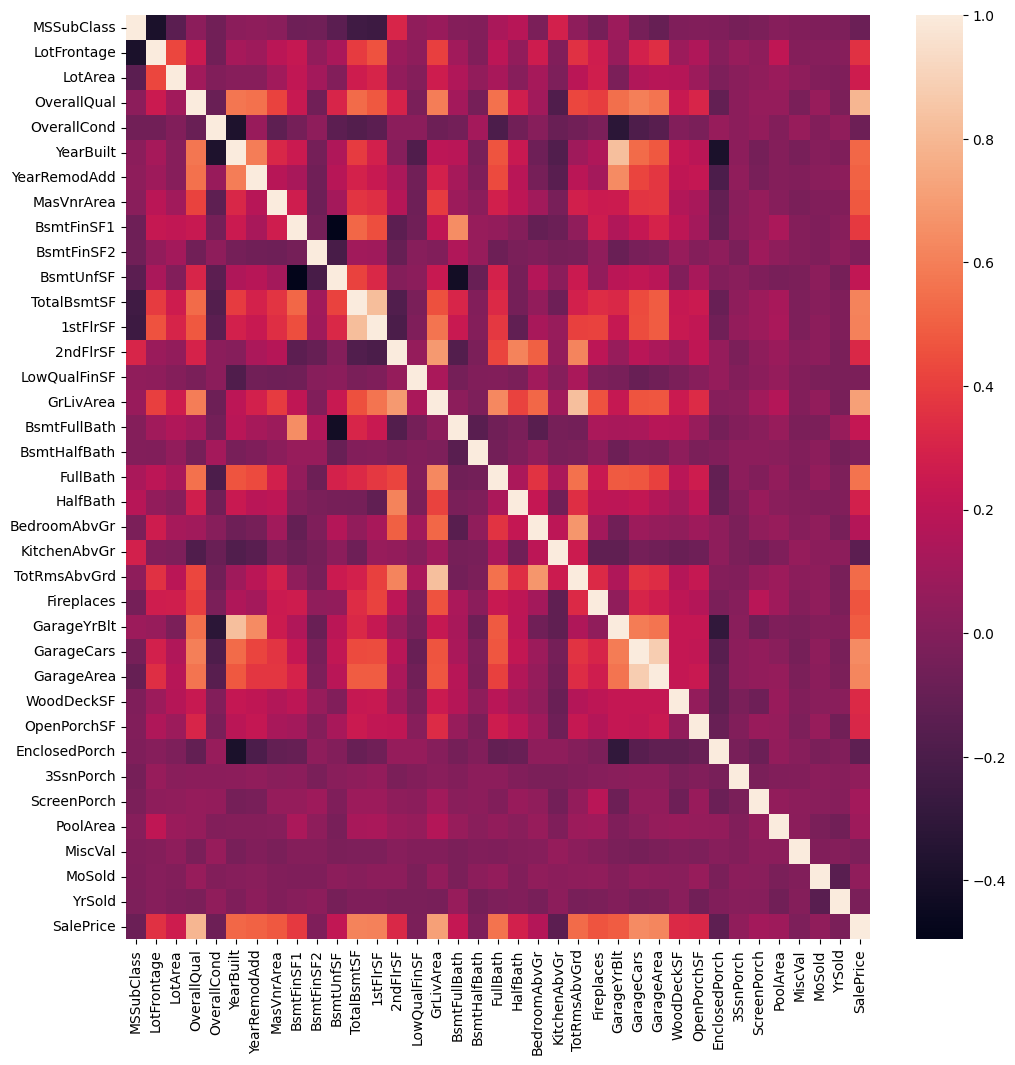

In [14]:
plt.figure(figsize=(12,12))
sns.heatmap(df_treino_numericas.corr())

In [18]:
df_treino_numericas_corr = df_treino_numericas.corr()

taxa_relevancia = 0.5

df_treino_numericas_corr_relevantes = df_treino_numericas_corr[
    ((df_treino_numericas_corr > taxa_relevancia) & (df_treino_numericas_corr < 1))
    |((df_treino_numericas_corr < -taxa_relevancia) & (df_treino_numericas_corr > -1))]
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True)
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True,axis=1)
df_treino_numericas_corr_relevantes

,OverallQual,YearBuilt,YearRemodAdd,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageCars,GarageArea,SalePrice
OverallQual,NaN,0.572323,0.550684,NaN,0.537808,NaN,NaN,0.593007,NaN,0.550600,NaN,NaN,NaN,0.547766,0.600671,0.562022,0.790982
YearBuilt,0.572323,NaN,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.825667,0.537850,NaN,0.522897
YearRemodAdd,0.550684,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.642277,NaN,NaN,0.507101
BsmtFinSF1,NaN,NaN,NaN,NaN,0.522396,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,0.537808,NaN,NaN,0.522396,NaN,0.819530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,0.819530,NaN,NaN,0.566024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.605852
2ndFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.687501,NaN,NaN,0.609707,0.502901,0.616423,NaN,NaN,NaN,NaN
GrLivArea,0.593007,NaN,NaN,NaN,NaN,0.566024,0.687501,NaN,NaN,0.630012,NaN,0.521270,0.825489,NaN,NaN,NaN,0.708624
BsmtFullBath,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullBath,0.550600,NaN,NaN,NaN,NaN,NaN,NaN,0.630012,NaN,NaN,NaN,NaN,0.554784,NaN,NaN,NaN,0.560664


A taxa de correlação mais alta de SalePrice está com OverallQual e YearBuilt

In [25]:

df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna()


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice'>

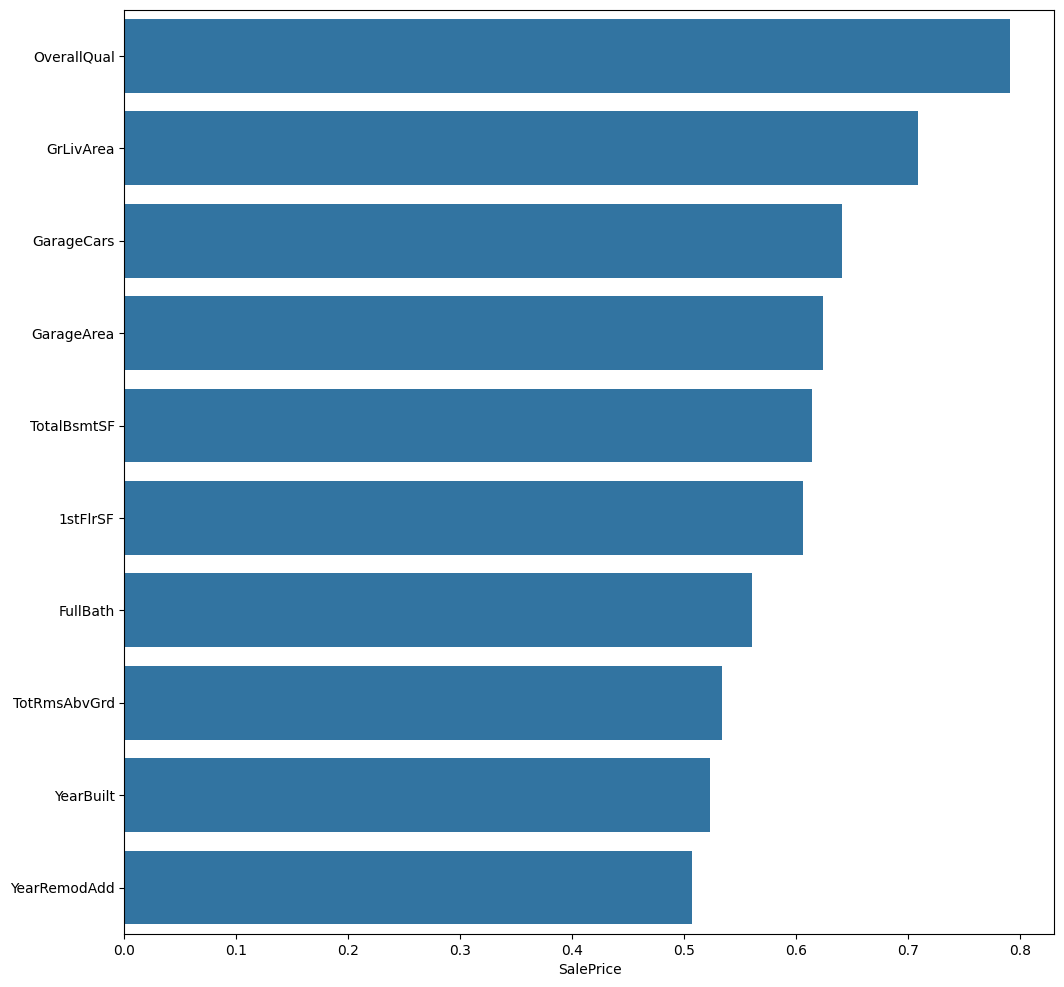

In [33]:
plt.figure(figsize=(12,12))
sns.barplot(
    df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna(),
    orient='y'
)

# Data Pre Processing

In [11]:
df_treino = df_treino.drop(['Id'],axis=1)

## Categorical Data

In [ ]:
# criar variáveis dummys

## Null Data

# Training Model

In [ ]:
# RandomForestRegressor

# Evaluating